In [1]:
import os
import glob
import time
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from concurrent.futures import ThreadPoolExecutor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
plt.style.use('dark_background')


In [2]:
OPTIONS_DIR = "/Users/sarthak/.cache/kagglehub/datasets/ayushsacri/indian-nifty-and-banknifty-options-data-2020-2024/versions/1/nifty_data/nifty_options"
SPOT_FILE = "/Users/sarthak/.cache/kagglehub/datasets/debashis74017/nifty-50-minute-data/versions/18/NIFTY 50_minute.csv"
CACHE_PATH = "/Users/sarthak/Desktop/gold_trading_bot/nifty_15m_dataset.parquet"

def parse_single_options_day(fpath):
    try:
        df = pd.read_csv(fpath)
        if df.empty or 'symbol' not in df.columns or 'date' not in df.columns or 'time' not in df.columns:
            return None

        is_pe = df['symbol'].astype(str).str.endswith('PE')
        is_ce = df['symbol'].astype(str).str.endswith('CE')

        pe_agg = df[is_pe].groupby(['date', 'time'])[['oi', 'volume', 'close']].agg({
            'oi': 'sum', 'volume': 'sum', 'close': 'mean'
        }).rename(columns={'oi': 'pe_oi', 'volume': 'pe_vol', 'close': 'pe_avg_price'})

        ce_agg = df[is_ce].groupby(['date', 'time'])[['oi', 'volume', 'close']].agg({
            'oi': 'sum', 'volume': 'sum', 'close': 'mean'
        }).rename(columns={'oi': 'ce_oi', 'volume': 'ce_vol', 'close': 'ce_avg_price'})

        merged = pd.concat([pe_agg, ce_agg], axis=1).fillna(0)
        return merged
    except Exception:
        return None

def load_or_build_nifty_dataset(reload=False):
    if not reload and os.path.exists(CACHE_PATH):
        print(f"Loading cached 15-minute dataset from {CACHE_PATH}...")
        return pd.read_parquet(CACHE_PATH)

    print("Extracting options files across 2023-2024...")
    all_files = sorted(glob.glob(os.path.join(OPTIONS_DIR, "*", "*", "*.csv")))

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = list(executor.map(parse_single_options_day, all_files))

    valid_dfs = [r for r in results if r is not None and not r.empty]
    df_opt = pd.concat(valid_dfs).reset_index()
    df_opt['datetime'] = pd.to_datetime(df_opt['date'] + ' ' + df_opt['time'])
    df_opt = df_opt.sort_values('datetime').drop_duplicates(subset=['datetime']).set_index('datetime')

    df_opt['total_oi'] = df_opt['pe_oi'] + df_opt['ce_oi']
    df_opt['total_vol'] = df_opt['pe_vol'] + df_opt['ce_vol']
    df_opt['pcr_oi'] = df_opt['pe_oi'] / (df_opt['ce_oi'] + 1e-6)
    df_opt['pcr_vol'] = df_opt['pe_vol'] / (df_opt['ce_vol'] + 1e-6)
    df_opt['oi_spread'] = (df_opt['pe_oi'] - df_opt['ce_oi']) / (df_opt['total_oi'] + 1e-6)
    df_opt['vol_spread'] = (df_opt['pe_vol'] - df_opt['ce_vol']) / (df_opt['total_vol'] + 1e-6)
    df_opt['ce_pe_premium_ratio'] = df_opt['ce_avg_price'] / (df_opt['pe_avg_price'] + 1e-6)

    df_spot = pd.read_csv(SPOT_FILE)
    df_spot.columns = [c.strip().lower() for c in df_spot.columns]
    df_spot['datetime'] = pd.to_datetime(df_spot['date'])
    df_spot = df_spot.sort_values('datetime').drop_duplicates(subset=['datetime']).set_index('datetime')

    min_date, max_date = df_opt.index.min(), df_opt.index.max()
    df_spot = df_spot[(df_spot.index >= min_date) & (df_spot.index <= max_date)]

    opt_cols_to_drop = [c for c in ['date', 'time'] if c in df_opt.columns]
    spot_cols_to_drop = [c for c in ['date'] if c in df_spot.columns]
    df_merged = df_spot.drop(columns=spot_cols_to_drop).join(df_opt.drop(columns=opt_cols_to_drop), how='inner')

    df_merged['date_only'] = df_merged.index.date
    daily_close = df_merged.groupby('date_only')['close'].last()
    daily_ema20 = daily_close.ewm(span=20, adjust=False).mean()
    daily_uptrend = (daily_close > daily_ema20).astype(int)

    df_merged['minute_of_day'] = df_merged.index.hour * 60 + df_merged.index.minute - (9 * 60 + 15)
    df_merged['day_of_week'] = df_merged.index.dayofweek
    df_merged['is_expiry_day'] = (df_merged['day_of_week'] == 3).astype(int)

    ohlc_15m_dict = {
        'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum',
        'pe_oi': 'last', 'ce_oi': 'last', 'pe_vol': 'sum', 'ce_vol': 'sum',
        'pcr_oi': 'last', 'pcr_vol': 'mean', 'oi_spread': 'last', 'vol_spread': 'mean',
        'ce_pe_premium_ratio': 'mean', 'minute_of_day': 'last', 'day_of_week': 'last', 'is_expiry_day': 'last'
    }
    df_15m = df_merged.resample('15min').agg(ohlc_15m_dict).dropna()
    df_15m = df_15m[(df_15m['minute_of_day'] >= 15) & (df_15m['minute_of_day'] <= 360)].copy()

    df_15m['date_only'] = df_15m.index.date
    df_15m['daily_trend'] = df_15m['date_only'].map(daily_uptrend).fillna(1).astype(int)

    df_15m['return_15m'] = df_15m['close'].pct_change(1)
    df_15m['return_45m'] = df_15m['close'].pct_change(3)
    df_15m['ema_9'] = df_15m['close'].ewm(span=9, adjust=False).mean()
    df_15m['ema_21'] = df_15m['close'].ewm(span=21, adjust=False).mean()
    df_15m['ema_spread'] = (df_15m['ema_9'] - df_15m['ema_21']) / df_15m['ema_21']

    delta = df_15m['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    df_15m['rsi_14'] = 100 - (100 / (1 + rs))

    hl = df_15m['high'] - df_15m['low']
    hc = (df_15m['high'] - df_15m['close'].shift()).abs()
    lc = (df_15m['low'] - df_15m['close'].shift()).abs()
    tr = pd.concat([hl, hc, lc], axis=1).max(axis=1)
    df_15m['atr_14'] = tr.rolling(14).mean()
    df_15m['normalized_atr'] = df_15m['atr_14'] / df_15m['close']

    df_15m['pcr_slope'] = df_15m['pcr_oi'] - df_15m['pcr_oi'].shift(3)
    df_15m['oi_spread_slope'] = df_15m['oi_spread'] - df_15m['oi_spread'].shift(3)

    fwd_ret = (df_15m['close'].shift(-4) - df_15m['close']) / df_15m['close']
    df_15m['forward_return'] = fwd_ret
    thresh = 0.35 * df_15m['normalized_atr']

    conditions = [fwd_ret > thresh, fwd_ret < -thresh]
    choices = [2, 0]
    df_15m['target'] = np.select(conditions, choices, default=1)

    df_15m.dropna(inplace=True)
    df_15m.to_parquet(CACHE_PATH)
    t1 = time.time()
    print(f"Dataset compiled in {t1-t0:.2f}s: {len(df_15m)} bars saved.")
    return df_15m

df = load_or_build_nifty_dataset()
print(f"Dataset Shape: {df.shape}")
print(f"Time Range:    {df.index.min()} to {df.index.max()}")
df[['close', 'pcr_oi', 'oi_spread', 'ema_spread', 'rsi_14', 'daily_trend', 'target']].head(10)


Loading cached 15-minute dataset from /Users/sarthak/Desktop/gold_trading_bot/nifty_15m_dataset.parquet...
Dataset Shape: (10390, 31)
Time Range:    2023-01-02 12:45:00 to 2024-10-31 14:00:00


,close,pcr_oi,oi_spread,ema_spread,rsi_14,daily_trend,target
datetime,,,,,,,
2023-01-02 12:45:00,18158.00,0.814753,-0.102078,0.000234,52.979374,0,1
2023-01-02 13:00:00,18182.35,0.852952,-0.079359,0.000279,60.354267,0,0
2023-01-02 13:15:00,18182.30,0.842242,-0.085634,0.000306,57.575758,0,0
2023-01-02 13:30:00,18171.40,0.861244,-0.074550,0.000255,52.768730,0,0
2023-01-02 13:45:00,18163.10,0.839965,-0.086977,0.000163,52.039833,0,2
2023-01-02 14:00:00,18170.10,0.752745,-0.141067,0.000136,44.968669,0,2
2023-01-02 14:15:00,18147.35,0.774827,-0.126871,-0.000024,39.190491,0,2
2023-01-02 14:30:00,18156.70,0.778525,-0.124527,-0.000083,40.658307,0,2
2023-01-02 14:45:00,18181.60,0.843272,-0.085027,0.000025,49.353863,0,2


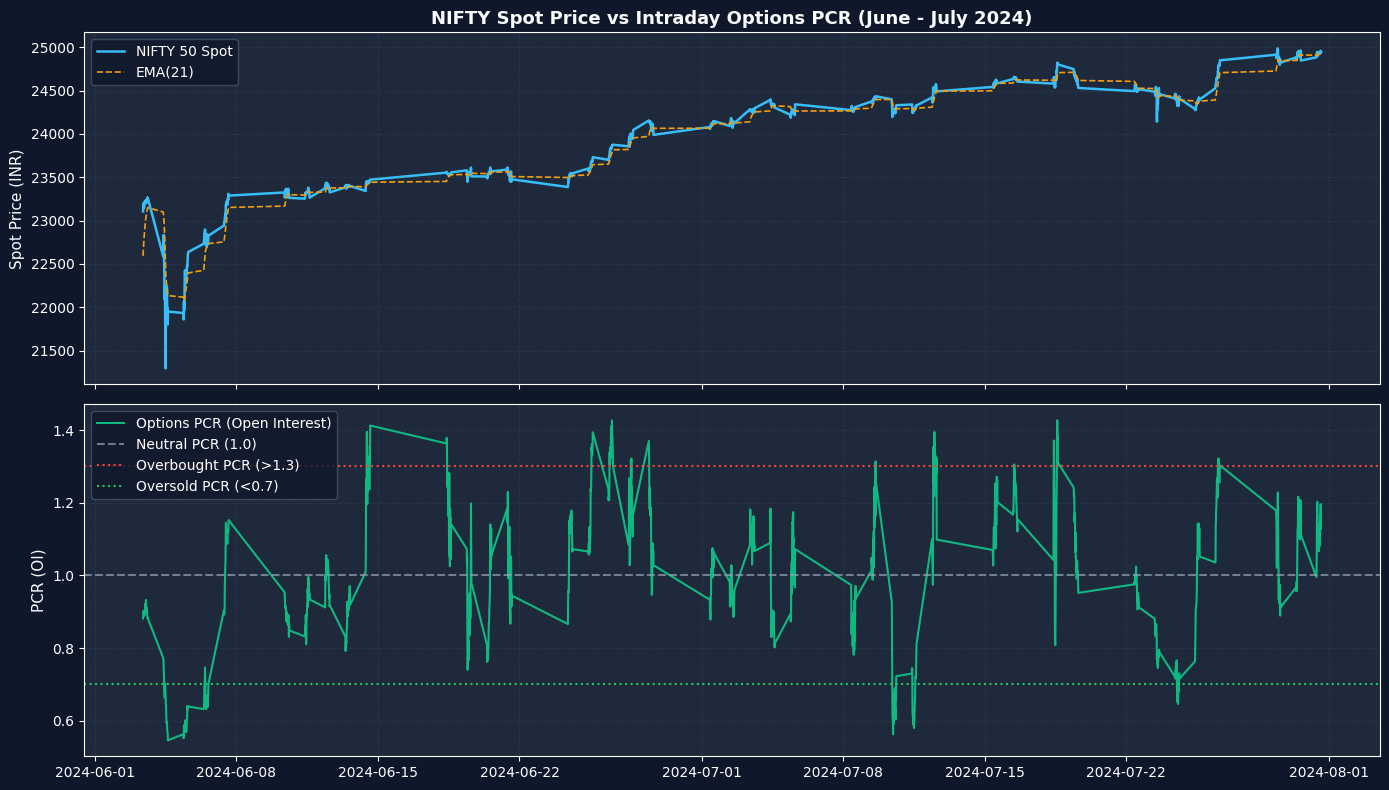

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.patch.set_facecolor('#0f172a')
for ax in (ax1, ax2):
    ax.set_facecolor('#1e293b')
    ax.grid(True, color='#334155', linestyle='--', alpha=0.5)

sample_slice = df.loc['2024-06-01':'2024-07-31']

ax1.plot(sample_slice.index, sample_slice['close'], color='#38bdf8', linewidth=1.8, label='NIFTY 50 Spot')
ax1.plot(sample_slice.index, sample_slice['ema_21'], color='#f59e0b', linestyle='--', linewidth=1.2, label='EMA(21)')
ax1.set_ylabel('Spot Price (INR)', color='#f8fafc', fontsize=11)
ax1.set_title('NIFTY Spot Price vs Intraday Options PCR (June - July 2024)', color='#f8fafc', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', facecolor='#0f172a', edgecolor='#475569')

ax2.plot(sample_slice.index, sample_slice['pcr_oi'], color='#10b981', linewidth=1.5, label='Options PCR (Open Interest)')
ax2.axhline(1.0, color='#94a3b8', linestyle='--', alpha=0.7, label='Neutral PCR (1.0)')
ax2.axhline(1.3, color='#ef4444', linestyle=':', label='Overbought PCR (>1.3)')
ax2.axhline(0.7, color='#22c55e', linestyle=':', label='Oversold PCR (<0.7)')
ax2.set_ylabel('PCR (OI)', color='#f8fafc', fontsize=11)
ax2.legend(loc='upper left', facecolor='#0f172a', edgecolor='#475569')

plt.tight_layout()
plt.show()


In [4]:
FEATURE_COLS = [
    'pcr_oi', 'pcr_vol', 'oi_spread', 'vol_spread', 'pcr_slope', 'oi_spread_slope', 'ce_pe_premium_ratio',
    'return_15m', 'return_45m', 'ema_spread', 'rsi_14', 'normalized_atr',
    'minute_of_day', 'day_of_week', 'is_expiry_day', 'daily_trend'
]

n = len(df)
n_train = int(n * 0.70)
train_df = df.iloc[:n_train].copy()
test_df = df.iloc[n_train:].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df['target']
X_test, y_test = test_df[FEATURE_COLS], test_df['target']

print(f"Train Set: {len(X_train)} bars ({train_df.index.min().date()} to {train_df.index.max().date()})")
print(f"Test Set:  {len(X_test)} bars ({test_df.index.min().date()} to {test_df.index.max().date()})")

clf = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.03,
    max_depth=4,
    min_samples_leaf=30,
    l2_regularization=3.0,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)
clf.fit(X_train, y_train)

probs_test = clf.predict_proba(X_test)
preds_test = np.argmax(probs_test, axis=1)

print(f"Out-of-Sample Accuracy: {accuracy_score(y_test, preds_test)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, preds_test, target_names=['Short (0)', 'Cash (1)', 'Long (2)']))

test_df['prob_short'] = probs_test[:, 0]
test_df['prob_cash'] = probs_test[:, 1]
test_df['prob_long'] = probs_test[:, 2]

probs_train = clf.predict_proba(X_train)
train_df['prob_short'] = probs_train[:, 0]
train_df['prob_cash'] = probs_train[:, 1]
train_df['prob_long'] = probs_train[:, 2]


Train Set: 7272 bars (2023-01-02 to 2024-04-16)
Test Set:  3118 bars (2024-04-16 to 2024-10-31)


Out-of-Sample Accuracy: 41.85%

Classification Report:
              precision    recall  f1-score   support

   Short (0)       0.40      0.36      0.38      1064
    Cash (1)       0.40      0.18      0.24       815
    Long (2)       0.43      0.63      0.51      1239

    accuracy                           0.42      3118
   macro avg       0.41      0.39      0.38      3118
weighted avg       0.41      0.42      0.40      3118



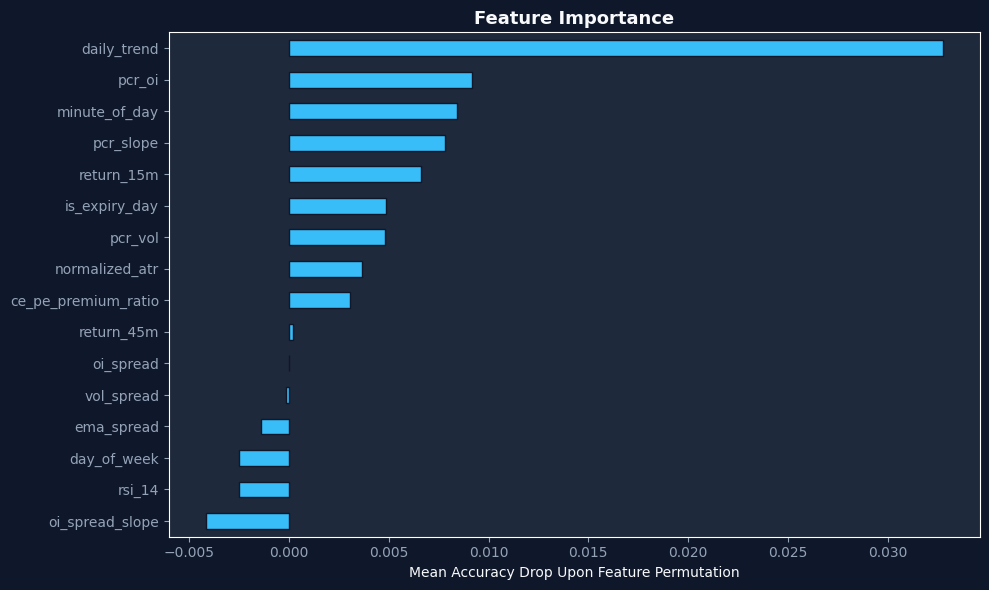

In [5]:
perm_imp = permutation_importance(clf, X_test, y_test, n_repeats=5, random_state=42)
imp_series = pd.Series(perm_imp.importances_mean, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 6), facecolor='#0f172a')
ax = plt.gca()
ax.set_facecolor('#1e293b')
ax.grid(True, color='#334155', linestyle='--', alpha=0.5)

imp_series.plot(kind='barh', color='#38bdf8', edgecolor='#0f172a', ax=ax)
plt.title('Feature Importance', color='#f8fafc', fontsize=13, fontweight='bold')
plt.xlabel('Mean Accuracy Drop Upon Feature Permutation', color='#f8fafc')
plt.tick_params(colors='#94a3b8')
plt.tight_layout()
plt.show()


In [6]:
def run_simulation(p_df, cost_per_trade=0.00025, target_risk=0.003, name="Backtest"):
    df_sim = p_df.copy()
    close = df_sim['close'].values
    high = df_sim['high'].values
    low = df_sim['low'].values
    atr = df_sim['atr_14'].values
    p_l = df_sim['prob_long'].values
    p_s = df_sim['prob_short'].values
    pcr = df_sim['pcr_oi'].values
    daily_tr = df_sim['daily_trend'].values
    mins = df_sim['minute_of_day'].values
    dates = df_sim.index

    positions = np.zeros(len(df_sim))
    position = 0
    entry_price = 0
    entry_atr = 0
    entry_time = dates[0]
    bars_held = 0
    max_profit = 0
    trade_logs = []

    for i in range(1, len(df_sim)):
        curr_min = mins[i]

        if curr_min >= 350:
            if position != 0:
                exit_price = close[i]
                pnl = (exit_price - entry_price)/entry_price if position == 1 else (entry_price - exit_price)/entry_price
                trade_logs.append({
                    'entry_time': entry_time, 'exit_time': dates[i],
                    'type': 'Long' if position == 1 else 'Short',
                    'entry_price': entry_price, 'exit_price': exit_price,
                    'pnl_pct': pnl, 'reason': 'EOD_Squareoff'
                })
            position = 0
            positions[i] = 0
            continue

        if position != 0:
            bars_held += 1
            if position == 1:
                gain = close[i] - entry_price
                max_profit = max(max_profit, gain)
                hit_sl = (entry_price - low[i]) >= (1.0 * entry_atr)
                hit_tp = gain >= (2.5 * entry_atr)
                hit_trail = (max_profit >= 1.5 * entry_atr) and ((max_profit - gain) >= 0.6 * entry_atr)
                hit_time = bars_held >= 10

                if hit_sl or hit_tp or hit_trail or hit_time:
                    exit_price = close[i]
                    pnl = (exit_price - entry_price) / entry_price
                    reason = 'Stop_Loss' if hit_sl else ('Take_Profit' if hit_tp else ('Trailing_Stop' if hit_trail else 'Time_Exit'))
                    trade_logs.append({
                        'entry_time': entry_time, 'exit_time': dates[i], 'type': 'Long',
                        'entry_price': entry_price, 'exit_price': exit_price, 'pnl_pct': pnl, 'reason': reason
                    })
                    position = 0
            elif position == -1:
                gain = entry_price - close[i]
                max_profit = max(max_profit, gain)
                hit_sl = (high[i] - entry_price) >= (1.0 * entry_atr)
                hit_tp = gain >= (2.5 * entry_atr)
                hit_trail = (max_profit >= 1.5 * entry_atr) and ((max_profit - gain) >= 0.6 * entry_atr)
                hit_time = bars_held >= 10

                if hit_sl or hit_tp or hit_trail or hit_time:
                    exit_price = close[i]
                    pnl = (entry_price - exit_price) / entry_price
                    reason = 'Stop_Loss' if hit_sl else ('Take_Profit' if hit_tp else ('Trailing_Stop' if hit_trail else 'Time_Exit'))
                    trade_logs.append({
                        'entry_time': entry_time, 'exit_time': dates[i], 'type': 'Short',
                        'entry_price': entry_price, 'exit_price': exit_price, 'pnl_pct': pnl, 'reason': reason
                    })
                    position = 0

        if position == 0 and curr_min < 300:
            if daily_tr[i] == 1 and p_l[i] > 0.35 and pcr[i] > 0.85:
                position = 1
                entry_price = close[i]
                entry_atr = atr[i]
                entry_time = dates[i]
                bars_held = 0
                max_profit = 0
            elif daily_tr[i] == 0 and p_s[i] > 0.35 and pcr[i] < 1.15:
                position = -1
                entry_price = close[i]
                entry_atr = atr[i]
                entry_time = dates[i]
                bars_held = 0
                max_profit = 0

        positions[i] = position

    df_sim['pos_exec'] = pd.Series(positions, index=df_sim.index).shift(1).fillna(0)
    df_sim.loc[df_sim['minute_of_day'] >= 355, 'pos_exec'] = 0

    df_sim['vol_size'] = (target_risk / (df_sim['normalized_atr'] + 1e-6)).clip(0.6, 1.4)
    df_sim['bar_ret'] = df_sim['close'].pct_change().fillna(0)
    df_sim['trades'] = df_sim['pos_exec'].diff().abs().fillna(0)

    df_sim['gross_strat_ret'] = df_sim['pos_exec'] * df_sim['bar_ret'] * df_sim['vol_size']
    df_sim['net_strat_ret'] = df_sim['gross_strat_ret'] - (df_sim['trades'] > 0.1) * cost_per_trade

    df_sim['strat_ret'] = df_sim['net_strat_ret'] if cost_per_trade > 0 else df_sim['gross_strat_ret']

    df_sim['cum_strat'] = (1 + df_sim['strat_ret']).cumprod()
    df_sim['cum_bh'] = (1 + df_sim['bar_ret']).cumprod()
    df_sim['peak'] = df_sim['cum_strat'].cummax()
    df_sim['drawdown'] = (df_sim['cum_strat'] - df_sim['peak']) / df_sim['peak']

    total_ret = df_sim['cum_strat'].iloc[-1] - 1
    bh_ret = df_sim['cum_bh'].iloc[-1] - 1
    max_dd = df_sim['drawdown'].min()

    daily_returns = df_sim['strat_ret'].resample('D').sum()
    daily_returns = daily_returns[daily_returns != 0]

    trading_days = len(daily_returns)
    sharpe = (daily_returns.mean() / (daily_returns.std() + 1e-9)) * np.sqrt(252)
    sortino = (daily_returns.mean() / (daily_returns[daily_returns < 0].std() + 1e-9)) * np.sqrt(252)
    calmar = abs((total_ret * (252 / max(trading_days, 1))) / (max_dd + 1e-9))

    trades_df = pd.DataFrame(trade_logs)
    num_trades = len(trades_df)
    win_trades = (trades_df['pnl_pct'] > 0).sum() if num_trades > 0 else 0
    win_rate = (win_trades / num_trades) if num_trades > 0 else 0
    gross_gains = trades_df.loc[trades_df['pnl_pct'] > 0, 'pnl_pct'].sum() if num_trades > 0 else 0
    gross_losses = abs(trades_df.loc[trades_df['pnl_pct'] < 0, 'pnl_pct'].sum()) if num_trades > 0 else 1e-9
    profit_factor = gross_gains / (gross_losses + 1e-9)

    time_in_market = (df_sim['pos_exec'] != 0).mean() * 100
    time_in_cash = (df_sim['pos_exec'] == 0).mean() * 100

    mode_str = "GROSS (0% Fees & Slippage)" if cost_per_trade == 0 else f"NET ({cost_per_trade*10000:.1f} bps Fees & Slippage)"
    print("=" * 65)
    print(f"      {name.upper()} — {mode_str}")
    print("=" * 65)
    print(f" Period:                 {df_sim.index.min().date()} to {df_sim.index.max().date()} ({trading_days} days)")
    print(f" Strategy Total Return:  {total_ret * 100:+.2f}%")
    print(f" Benchmark Buy & Hold:   {bh_ret * 100:+.2f}%")
    print(f" Annualized Sharpe:      {sharpe:.2f}")
    print(f" Annualized Sortino:     {sortino:.2f}")
    print(f" Maximum Drawdown (MDD): {max_dd * 100:.2f}%")
    print(f" Calmar Ratio:           {calmar:.2f}")
    print(f" Total Completed Trades: {num_trades} (~{num_trades / max(trading_days, 1):.1f} trades/day)")
    print(f" Win Rate:               {win_rate * 100:.1f}%")
    print(f" Profit Factor:          {profit_factor:.2f}")
    print(f" Time in Market:         {time_in_market:.1f}%")
    print(f" Time in Cash:           {time_in_cash:.1f}%")
    print("=" * 65 + "\n")

    return {
        'total_return': total_ret, 'benchmark_return': bh_ret,
        'sharpe_ratio': sharpe, 'sortino_ratio': sortino,
        'max_drawdown': max_dd, 'calmar_ratio': calmar,
        'total_trades': num_trades, 'win_rate': win_rate,
        'profit_factor': profit_factor, 'df': df_sim, 'trades_df': trades_df
    }

test_gross = run_simulation(test_df, cost_per_trade=0.0, name="Test Set (Gross)")

test_net = run_simulation(test_df, cost_per_trade=0.00025, name="Test Set (Net)")
test_res = test_gross


      TEST SET (GROSS) — GROSS (0% Fees & Slippage)
 Period:                 2024-04-16 to 2024-10-31 (126 days)
 Strategy Total Return:  +27.25%
 Benchmark Buy & Hold:   +9.34%
 Annualized Sharpe:      4.81
 Annualized Sortino:     7.74
 Maximum Drawdown (MDD): -2.78%
 Calmar Ratio:           19.62
 Total Completed Trades: 408 (~3.2 trades/day)
 Win Rate:               48.5%
 Profit Factor:          1.63
 Time in Market:         70.6%
 Time in Cash:           29.4%

      TEST SET (NET) — NET (2.5 bps Fees & Slippage)
 Period:                 2024-04-16 to 2024-10-31 (126 days)
 Strategy Total Return:  +16.96%
 Benchmark Buy & Hold:   +9.34%
 Annualized Sharpe:      3.14
 Annualized Sortino:     5.03
 Maximum Drawdown (MDD): -3.20%
 Calmar Ratio:           10.60
 Total Completed Trades: 408 (~3.2 trades/day)
 Win Rate:               48.5%
 Profit Factor:          1.63
 Time in Market:         70.6%
 Time in Cash:           29.4%



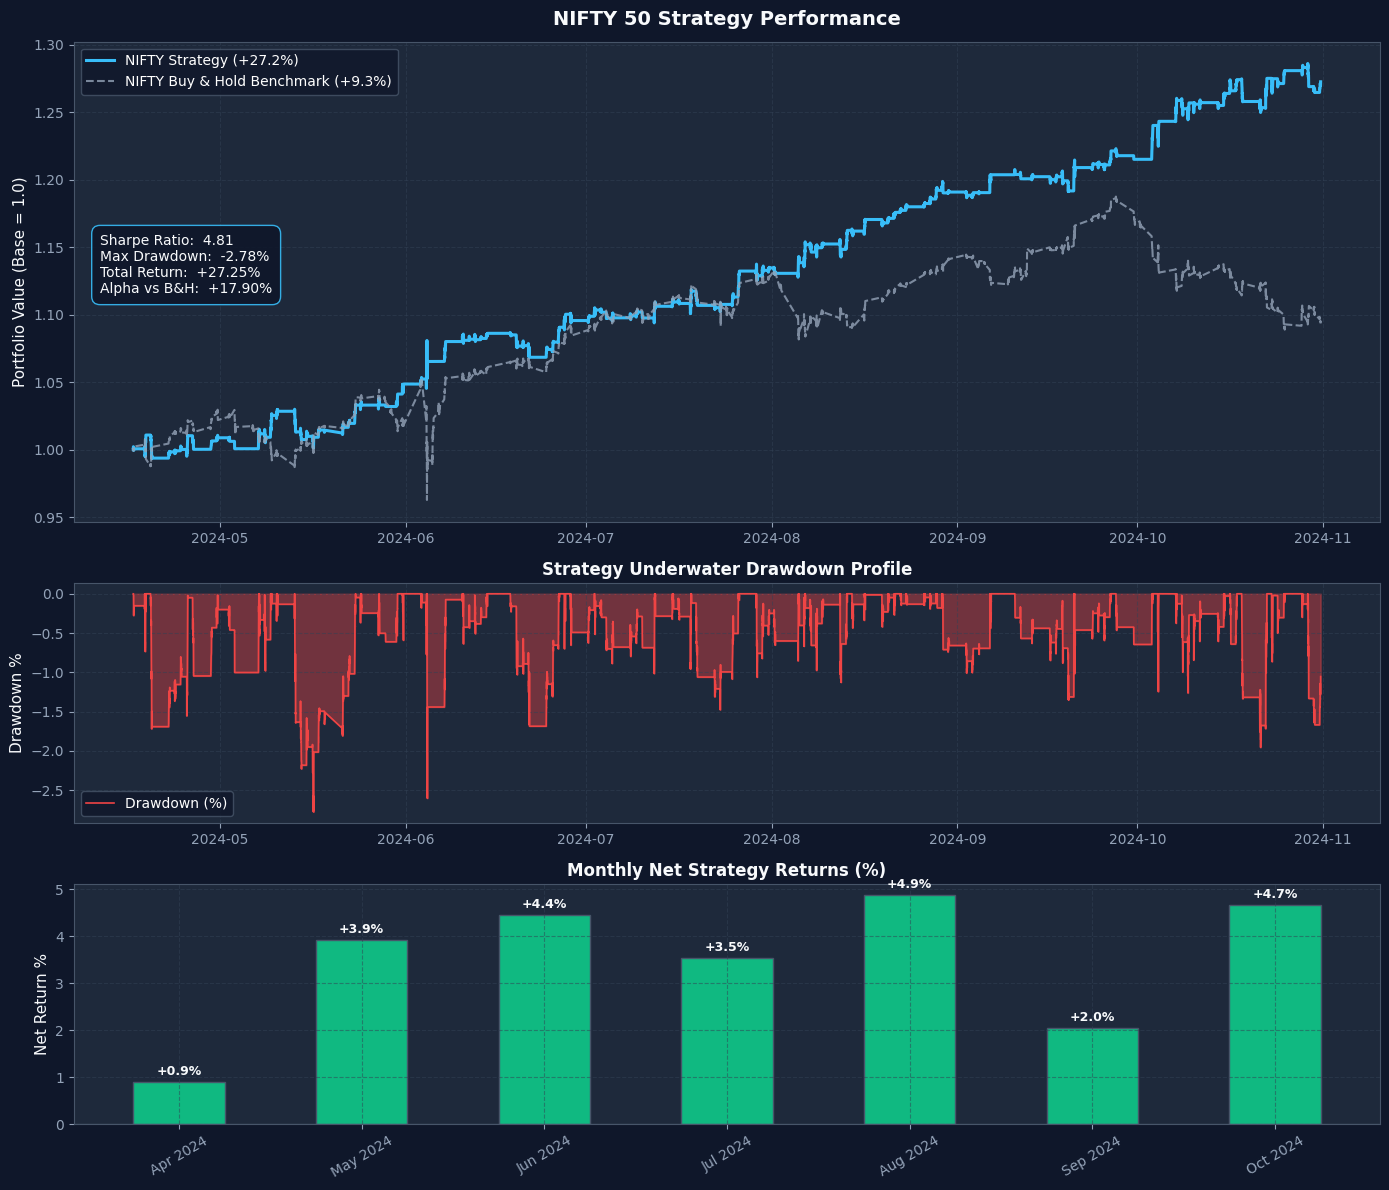

In [7]:
sim_df = test_res['df']
total_ret = test_res['total_return']
bh_ret = test_res['benchmark_return']
sharpe = test_res['sharpe_ratio']
max_dd = test_res['max_drawdown']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
fig.patch.set_facecolor('#0f172a')

for ax in axes:
    ax.set_facecolor('#1e293b')
    ax.grid(True, color='#334155', linestyle='--', alpha=0.5)
    ax.tick_params(colors='#94a3b8', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#475569')

ax1 = axes[0]
ax1.plot(sim_df.index, sim_df['cum_strat'], label=f'NIFTY Strategy ({total_ret*100:+.1f}%)', color='#38bdf8', linewidth=2.2)
ax1.plot(sim_df.index, sim_df['cum_bh'], label=f'NIFTY Buy & Hold Benchmark ({bh_ret*100:+.1f}%)', color='#94a3b8', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.set_title("NIFTY 50 Strategy Performance", color='#f8fafc', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel("Portfolio Value (Base = 1.0)", color='#f8fafc', fontsize=11)
ax1.legend(loc='upper left', framealpha=0.8, facecolor='#0f172a', edgecolor='#475569', fontsize=10)

stats_text = (
    f"Sharpe Ratio:  {sharpe:.2f}\n"
    f"Max Drawdown:  {max_dd*100:.2f}%\n"
    f"Total Return:  {total_ret*100:+.2f}%\n"
    f"Alpha vs B&H:  {(total_ret - bh_ret)*100:+.2f}%"
)
ax1.text(0.02, 0.60, stats_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.6', facecolor='#0f172a', edgecolor='#38bdf8', alpha=0.9), color='#f8fafc')

ax2 = axes[1]
ax2.fill_between(sim_df.index, sim_df['drawdown'] * 100, 0, color='#ef4444', alpha=0.4)
ax2.plot(sim_df.index, sim_df['drawdown'] * 100, color='#ef4444', linewidth=1.2, label='Drawdown (%)')
ax2.set_title("Strategy Underwater Drawdown Profile", color='#f8fafc', fontsize=12, fontweight='bold')
ax2.set_ylabel("Drawdown %", color='#f8fafc', fontsize=11)
ax2.legend(loc='lower left', framealpha=0.8, facecolor='#0f172a', edgecolor='#475569')

ax3 = axes[2]
monthly_ret = sim_df['strat_ret'].resample('ME').sum() * 100
months_str = [m.strftime('%b %Y') for m in monthly_ret.index]
colors = ['#10b981' if r >= 0 else '#ef4444' for r in monthly_ret]
bars = ax3.bar(months_str, monthly_ret, color=colors, edgecolor='#475569', width=0.5)
ax3.axhline(0, color='#94a3b8', linestyle='-', linewidth=0.8)
ax3.set_title("Monthly Net Strategy Returns (%)", color='#f8fafc', fontsize=12, fontweight='bold')
ax3.set_ylabel("Net Return %", color='#f8fafc', fontsize=11)
ax3.tick_params(axis='x', rotation=30)

for bar in bars:
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    ax3.annotate(f'{height:+.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -8),
                textcoords="offset points",
                ha='center', va=va, fontsize=9, color='#f8fafc', fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
trades_df = test_res['trades_df']
print(f"Total Trades: {len(trades_df)}")
print(f"Winning Trades:             {(trades_df['pnl_pct'] > 0).sum()} ({(trades_df['pnl_pct'] > 0).mean()*100:.1f}%)")
print(f"Average Win:                +{trades_df.loc[trades_df['pnl_pct'] > 0, 'pnl_pct'].mean()*100:.2f}%")
print(f"Average Loss:               {trades_df.loc[trades_df['pnl_pct'] < 0, 'pnl_pct'].mean()*100:.2f}%")
print("\nExit Reason Breakdown:")
print(trades_df['reason'].value_counts())
print("\nSample Recent Trades:")
display(trades_df.tail(10))


Total Trades: 408
Winning Trades:             198 (48.5%)
Average Win:                +0.29%
Average Loss:               -0.17%

Exit Reason Breakdown:
reason
Stop_Loss        180
Time_Exit         86
EOD_Squareoff     59
Take_Profit       51
Trailing_Stop     32
Name: count, dtype: int64

Sample Recent Trades:


,entry_time,exit_time,type,entry_price,exit_price,pnl_pct,reason
398,2024-10-25 10:00:00,2024-10-25 11:15:00,Short,24238.85,24147.35,0.003775,Take_Profit
399,2024-10-25 11:15:00,2024-10-25 13:45:00,Short,24147.35,24108.75,0.001599,Time_Exit
400,2024-10-28 11:30:00,2024-10-28 12:30:00,Short,24427.85,24451.80,-0.000980,Stop_Loss
401,2024-10-28 12:30:00,2024-10-28 15:00:00,Short,24451.80,24343.90,0.004413,EOD_Squareoff
402,2024-10-29 09:45:00,2024-10-29 12:00:00,Short,24212.55,24293.75,-0.003354,Stop_Loss
403,2024-10-29 12:00:00,2024-10-29 14:00:00,Short,24293.75,24417.50,-0.005094,Stop_Loss
404,2024-10-30 09:30:00,2024-10-30 11:15:00,Short,24401.05,24443.85,-0.001754,Stop_Loss
405,2024-10-30 11:45:00,2024-10-30 13:00:00,Short,24446.95,24429.10,0.000730,Stop_Loss
406,2024-10-30 14:00:00,2024-10-30 14:30:00,Short,24324.10,24359.05,-0.001437,Stop_Loss
407,2024-10-31 09:45:00,2024-10-31 12:15:00,Short,24295.05,24223.40,0.002949,Time_Exit
